# Korpus-Analyse: Semantische Ähnlichkeit, Textlängen, Bidirektionale Named Entities & Diversität (TTR/MATTR)

Dieses Notebook bietet eine eingehende linguistische und korpusdiagnostische Analyse des parallelen Gesamtkorpus (Alltagssprache **AS** vs. Leichte Sprache **LS**).

### Analysierte Dimensionen:
1. **Verteilung der Textlängen**: Token- und Wortanzahlen, Längenverhältnisse (Kompression vs. Expansion) und Perzentile über verschiedene Quellen.
2. **Semantische Ähnlichkeit**: Verteilung der paarweisen Cosine Similarity (SBERT Jina 8192) über das Gesamtkorpus und aufgeschlüsselt nach Quellen.
3. **Named Entity Recognition (NER) & Bidirektionaler Faktenerhalt**:
   - **Faktenerhalt ($AS \to LS$)**: Welche Eigennamen, Orte und Organisationen aus der Alltagssprache überleben in Leichter Sprache?
   - **Faktentreue ($LS \to AS$)**: Führt Leichte Sprache neue Entitäten ein oder verändert sie bestehende Fakten?
   - **Asymmetrie- & Generalisierungsanalyse**: Warum ist die Schnittmenge gering? (Umschreibung zu Gattungsbegriffen wie *Arbeitsagentur* $\to$ *Amt*).
   - **Entitäts-Kompression**: Absolute Entitätsanzahlen und Typenmuster.
4. **Lexikalische Vielfalt (TTR - Type-Token Ratio)**: Analyse der klassischen TTR ($V/N$), deren Vergleich zwischen AS und LS sowie Untersuchung des textlängenbedingten TTR-Bias.
5. **Robuste lexikalische Vielfalt (MATTR - Moving-Average Type-Token Ratio)**: Fensterbasierte MATTR ($W=50$), Gegenüberstellung zu TTR und Nachweis der Längenunabhängigkeit.
6. **Multivariate Zusammenhänge & Gesamttabelle**: Korrelationsmatrix aller Dimensionen und deskriptive Gesamttabelle für die Masterarbeit.


In [1]:
import os
import re
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import spacy

# Plot-Styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 11

print("Bibliotheken erfolgreich importiert.")


Bibliotheken erfolgreich importiert.


## 1. Datensatz laden

Wir laden die Master-CSV-Datei (`data/analysis/corpus_master.csv`), die alle vorberechneten Textpaare, semantischen Ähnlichkeiten, bidirektionalen NER-Werte sowie Lesbarkeits- und Diversitätsmetriken enthält.


In [2]:
# Pfad zur Master-CSV-Datei
csv_candidates = [
    "../../../data/analysis/corpus_master.csv",
    "../../data/analysis/corpus_master.csv",
    "data/analysis/corpus_master.csv"
]
CSV_PATH = next((p for p in csv_candidates if os.path.exists(p)), "data/analysis/corpus_master.csv")

df = pd.read_csv(CSV_PATH)
print(f"Erfolgreich {len(df)} Artikelpaare geladen aus: {CSV_PATH}")

# Berechnung des Längenverhältnisses LS / AS
if "ratio_ls_as" not in df.columns and "as_tokens" in df.columns and "ls_tokens" in df.columns:
    df["ratio_ls_as"] = df["ls_tokens"] / df["as_tokens"]

print(f"Spalten im DataFrame ({len(df.columns)}):", list(df.columns))
df[["source", "semantic_similarity_8192", "ner_recall_as_ls", "ner_recall_ls_as", "as_ent_count", "ls_ent_count", "as_tokens", "ls_tokens"]].head(3)


Erfolgreich 882 Artikelpaare geladen aus: ../../../data/analysis/corpus_master.csv
Spalten im DataFrame (25): ['source', 'as_url', 'ls_url', 'as_text', 'ls_text', 'semantic_similarity_8192', 'ner_recall_as_ls', 'ner_recall_ls_as', 'as_ent_count', 'ls_ent_count', 'as_tokens', 'ls_tokens', 'as_avg_sent_len', 'ls_avg_sent_len', 'as_flesch', 'as_wiener', 'as_lix', 'ls_flesch', 'ls_wiener', 'ls_lix', 'as_ttr', 'as_mattr', 'ls_ttr', 'ls_mattr', 'ratio_ls_as']


,source,semantic_similarity_8192,ner_recall_as_ls,ner_recall_ls_as,as_ent_count,ls_ent_count,as_tokens,ls_tokens
0,hamburg,0.879659,0.250000,0.166667,16,24,238,675
1,hamburg,0.877679,0.357143,0.227273,14,22,304,515
2,hamburg,0.842175,0.111111,0.041667,9,24,420,989


### 1.1 Mathematische & Algorithmische Definitionen (TTR, MATTR & Bidirektionales NER)

Für Transparenz und Reproduzierbarkeit sind hier die mathematischen und algorithmischen Definitionen hinterlegt:

- **Type-Token Ratio (TTR)**:
  $$TTR = \frac{|V|}{N}$$
  wobei $|V|$ die Anzahl der einzigartigen Lemmata/Wortformen (Types) und $N$ die Gesamtwortanzahl (Tokens) ist.

- **Moving-Average Type-Token Ratio (MATTR)**:
  Berechnung von TTR über ein gleitendes Fenster der festen Breite $W$ (Standard: $W=50$):
  $$MATTR = \frac{1}{N - W + 1} \sum_{i=1}^{N - W + 1} \frac{|V_{i, W}|}{W}$$

- **Bidirektionaler Named Entity Recall (NER)**:
  Sei $E_{AS}$ die Menge aller in der Alltagssprache extrahierten Entitäten (Personen, Orte, Organisationen) und $E_{LS}$ die Menge der Entitäten in Leichter Sprache:
  
  1. **Faktenerhalt ($AS \to LS$, Standard Recall)**:
     $$\text{Recall}_{AS \to LS} = \frac{|E_{AS} \cap E_{LS}|}{|E_{AS}|}$$
     Gibt an, welcher Anteil der im Original genannten Entitäten in der vereinfachten Version erhalten bleibt.
     
  2. **Faktentreue / Inverted Recall ($LS \to AS$)**:
     $$\text{Recall}_{LS \to AS} = \frac{|E_{LS} \cap E_{AS}|}{|E_{LS}|}$$
     Gibt an, welcher Anteil der in Leichter Sprache vorkommenden Entitäten im Ausgangstext verankert ist (Prüfung auf neue/erfundene Fakten oder Umschreibungen).


In [3]:
def compute_ttr_and_mattr(text, window_size=50):
    """Berechnet einfache Wort-Tokens, TTR und MATTR für einen Text."""
    if not isinstance(text, str) or len(text.strip()) == 0:
        return 0, np.nan, np.nan
    tokens = re.findall(r'\b\w+\b', text.lower())
    n_tokens = len(tokens)
    if n_tokens == 0:
        return 0, np.nan, np.nan
    unique_types = len(set(tokens))
    ttr = unique_types / n_tokens
    if n_tokens < window_size:
        mattr = ttr
    else:
        window_ttrs = [
            len(set(tokens[i : i + window_size])) / window_size
            for i in range(n_tokens - window_size + 1)
        ]
        mattr = float(np.mean(window_ttrs))
    return n_tokens, ttr, mattr

def extract_entities_and_recall(as_text, ls_text, nlp_model=None):
    """Extrahiert Named Entities mit spaCy und berechnet den bidirektionalen Recall."""
    if nlp_model is None:
        nlp_model = spacy.load("de_core_news_lg")
    as_doc = nlp_model(as_text)
    ls_doc = nlp_model(ls_text)
    
    as_ents = set([ent.text.lower().strip() for ent in as_doc.ents])
    ls_ents = set([ent.text.lower().strip() for ent in ls_doc.ents])
    
    overlap = as_ents.intersection(ls_ents)
    recall_as_ls = len(overlap) / len(as_ents) if as_ents else 1.0
    recall_ls_as = len(overlap) / len(ls_ents) if ls_ents else 1.0
    
    return {
        "as_ents": as_ents,
        "ls_ents": ls_ents,
        "overlap": overlap,
        "as_lost": as_ents - ls_ents,
        "ls_added": ls_ents - as_ents,
        "recall_as_ls": recall_as_ls,
        "recall_ls_as": recall_ls_as
    }

# Test an einem exemplarischen Satzpaar
test_as = "Bundeskanzler Olaf Scholz besuchte am Montag die Charité in Berlin, um über die Pflegereform zu sprechen."
test_ls = "Olaf Scholz ist der Bundes-Kanzler. Er war am Montag in Berlin in einem großen Kranken-Haus."

res_test = extract_entities_and_recall(test_as, test_ls)
print("=== Demonstration der NER-Referenzfunktion ===")
print(f"AS Entitäten ({len(res_test['as_ents'])}):", res_test["as_ents"])
print(f"LS Entitäten ({len(res_test['ls_ents'])}):", res_test["ls_ents"])
print(f"Überlappung ({len(res_test['overlap'])}):", res_test["overlap"])
print(f"In AS verloren ({len(res_test['as_lost'])}):", res_test["as_lost"])
print(f"In LS neu/umformuliert ({len(res_test['ls_added'])}):", res_test["ls_added"])
print(f"Faktenerhalt (AS -> LS): {res_test['recall_as_ls']:.2%}")
print(f"Faktentreue  (LS -> AS): {res_test['recall_ls_as']:.2%}")


=== Demonstration der NER-Referenzfunktion ===
AS Entitäten (3): {'charité', 'berlin', 'olaf scholz'}
LS Entitäten (2): {'berlin', 'olaf scholz'}
Überlappung (2): {'berlin', 'olaf scholz'}
In AS verloren (1): {'charité'}
In LS neu/umformuliert (0): set()
Faktenerhalt (AS -> LS): 66.67%
Faktentreue  (LS -> AS): 100.00%


## 2. Korpus-Übersicht nach Quellen

Deskriptive Kennzahlen für jede Datenquelle: Artikelpaare, Gesamttokens, durchschnittliche Längen, mittlere semantische Ähnlichkeit, bidirektionaler NER-Recall (Faktenerhalt & Faktentreue) und MATTR-Diversität.


In [4]:
# Aggregation pro Quelle inklusive NER-Kennzahlen
summary_df = df.groupby("source").agg(
    Artikelpaare=("as_tokens", "count"),
    Tokens_AS_Gesamt=("as_tokens", "sum"),
    Tokens_LS_Gesamt=("ls_tokens", "sum"),
    Ø_Tokens_AS=("as_tokens", "mean"),
    Ø_Tokens_LS=("ls_tokens", "mean"),
    Ø_Ähnlichkeit=("semantic_similarity_8192", "mean") if "semantic_similarity_8192" in df.columns else ("as_tokens", "count"),
    Ø_NER_AS_LS=("ner_recall_as_ls", "mean") if "ner_recall_as_ls" in df.columns else ("as_tokens", "count"),
    Ø_NER_LS_AS=("ner_recall_ls_as", "mean") if "ner_recall_ls_as" in df.columns else ("as_tokens", "count"),
    Ø_Ent_AS=("as_ent_count", "mean") if "as_ent_count" in df.columns else ("as_tokens", "count"),
    Ø_Ent_LS=("ls_ent_count", "mean") if "ls_ent_count" in df.columns else ("as_tokens", "count"),
    Ø_MATTR_AS=("as_mattr", "mean") if "as_mattr" in df.columns else ("as_tokens", "count"),
    Ø_MATTR_LS=("ls_mattr", "mean") if "ls_mattr" in df.columns else ("as_tokens", "count")
)
summary_df["Längenratio_LS_AS"] = summary_df["Tokens_LS_Gesamt"] / summary_df["Tokens_AS_Gesamt"]

# Gesamtsummen-Zeile
total_row = pd.Series({
    "Artikelpaare": len(df),
    "Tokens_AS_Gesamt": df["as_tokens"].sum(),
    "Tokens_LS_Gesamt": df["ls_tokens"].sum(),
    "Ø_Tokens_AS": df["as_tokens"].mean(),
    "Ø_Tokens_LS": df["ls_tokens"].mean(),
    "Ø_Ähnlichkeit": df["semantic_similarity_8192"].mean() if "semantic_similarity_8192" in df.columns else np.nan,
    "Ø_NER_AS_LS": df["ner_recall_as_ls"].mean() if "ner_recall_as_ls" in df.columns else np.nan,
    "Ø_NER_LS_AS": df["ner_recall_ls_as"].mean() if "ner_recall_ls_as" in df.columns else np.nan,
    "Ø_Ent_AS": df["as_ent_count"].mean() if "as_ent_count" in df.columns else np.nan,
    "Ø_Ent_LS": df["ls_ent_count"].mean() if "ls_ent_count" in df.columns else np.nan,
    "Ø_MATTR_AS": df["as_mattr"].mean() if "as_mattr" in df.columns else np.nan,
    "Ø_MATTR_LS": df["ls_mattr"].mean() if "ls_mattr" in df.columns else np.nan,
    "Längenratio_LS_AS": df["ls_tokens"].sum() / df["as_tokens"].sum()
}, name="GESAMT")

summary_table = pd.concat([summary_df, pd.DataFrame([total_row])])
display(summary_table.round(3))


,Artikelpaare,Tokens_AS_Gesamt,Tokens_LS_Gesamt,Ø_Tokens_AS,Ø_Tokens_LS,Ø_Ähnlichkeit,Ø_NER_AS_LS,Ø_NER_LS_AS,Ø_Ent_AS,Ø_Ent_LS,Ø_MATTR_AS,Ø_MATTR_LS,Längenratio_LS_AS
apotheken,154.0,183061.0,102106.0,1188.708,663.026,0.844,0.081,0.259,25.883,7.091,0.804,0.675,0.558
behindertenbeauftragter,49.0,19408.0,19192.0,396.082,391.673,0.862,0.338,0.334,15.551,19.327,0.756,0.693,0.989
brandeins,18.0,3404.0,3542.0,189.111,196.778,0.706,0.205,0.387,5.944,4.944,0.799,0.681,1.041
hamburg,49.0,23141.0,21874.0,472.265,446.408,0.820,0.147,0.118,16.204,16.490,0.772,0.657,0.945
hannover,229.0,112318.0,118437.0,490.472,517.192,0.839,0.270,0.374,19.760,12.598,0.768,0.653,1.054
koeln,37.0,19464.0,27699.0,526.054,748.622,0.823,0.167,0.090,14.486,27.081,0.752,0.670,1.423
main_taunus,34.0,5330.0,5353.0,156.765,157.441,0.816,0.311,0.254,6.765,6.059,0.789,0.722,1.004
mdr,222.0,76650.0,46148.0,345.270,207.874,0.792,0.166,0.271,23.045,13.027,0.803,0.703,0.602
sozialpolitik,14.0,11311.0,4912.0,807.929,350.857,0.780,0.107,0.255,24.429,12.357,0.804,0.711,0.434
stuttgart,37.0,32325.0,21275.0,873.649,575.000,0.838,0.244,0.176,21.811,22.297,0.761,0.686,0.658


## 3. Verteilung der Textlängen (Tokens & Ratio)

Untersuchung der Längenverteilung von Alltagssprache (AS) und Leichter Sprache (LS) sowie des Kompressions-/Expansionsverhaltens.


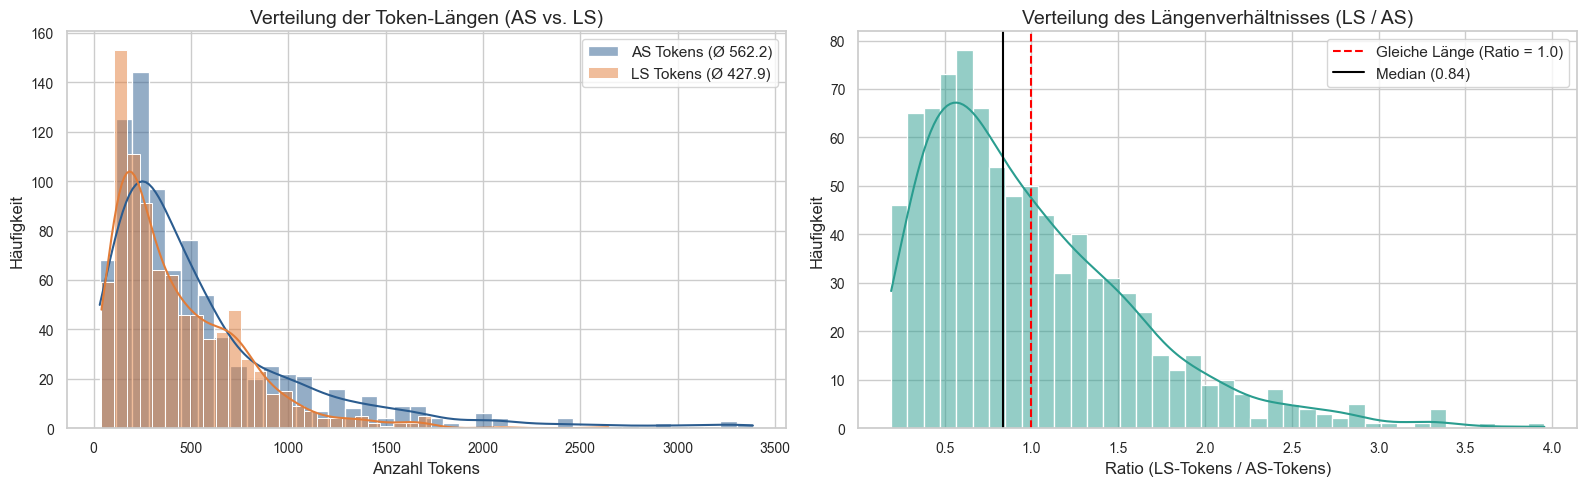

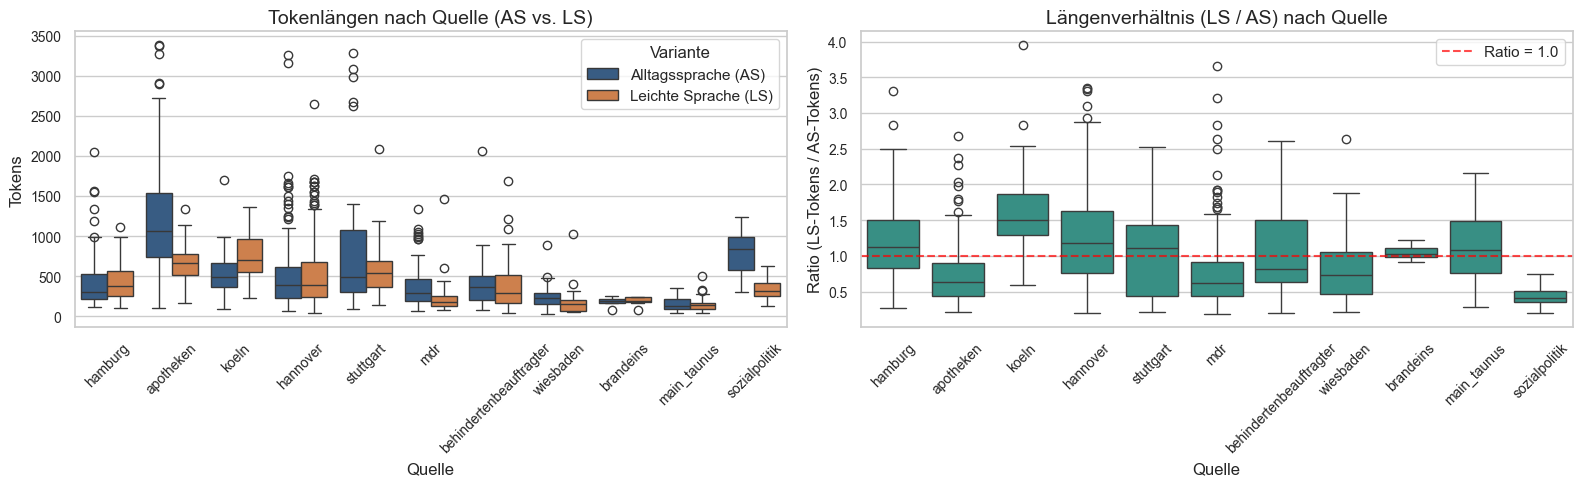

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 3.1 Verteilung der Tokenanzahlen (Histogramm & KDE)
sns.histplot(df["as_tokens"], kde=True, color="#2b5c8f", label=f"AS Tokens (Ø {df['as_tokens'].mean():.1f})", bins=40, alpha=0.5, ax=axes[0])
sns.histplot(df["ls_tokens"], kde=True, color="#e27c38", label=f"LS Tokens (Ø {df['ls_tokens'].mean():.1f})", bins=40, alpha=0.5, ax=axes[0])
axes[0].set_title("Verteilung der Token-Längen (AS vs. LS)")
axes[0].set_xlabel("Anzahl Tokens")
axes[0].set_ylabel("Häufigkeit")
axes[0].legend()

# 3.2 Längenverhältnis LS / AS (Kompression vs. Expansion)
if "ratio_ls_as" in df.columns:
    sns.histplot(df["ratio_ls_as"], kde=True, color="#2a9d8f", bins=40, ax=axes[1])
    axes[1].axvline(1.0, color="red", linestyle="--", label="Gleiche Länge (Ratio = 1.0)")
    axes[1].axvline(df["ratio_ls_as"].median(), color="black", linestyle="-", label=f"Median ({df['ratio_ls_as'].median():.2f})")
    axes[1].set_title("Verteilung des Längenverhältnisses (LS / AS)")
    axes[1].set_xlabel("Ratio (LS-Tokens / AS-Tokens)")
    axes[1].set_ylabel("Häufigkeit")
    axes[1].legend()

plt.tight_layout()
plt.show()

# Boxplot der Token-Längen nach Quellen
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
df_melted = df.melt(id_vars=["source"], value_vars=["as_tokens", "ls_tokens"], 
                    var_name="Variante", value_name="Tokens")
df_melted["Variante"] = df_melted["Variante"].map({"as_tokens": "Alltagssprache (AS)", "ls_tokens": "Leichte Sprache (LS)"})

sns.boxplot(data=df_melted, x="source", y="Tokens", hue="Variante", palette=["#2b5c8f", "#e27c38"], ax=axes[0])
axes[0].set_title("Tokenlängen nach Quelle (AS vs. LS)")
axes[0].set_xlabel("Quelle")
axes[0].set_ylabel("Tokens")
axes[0].tick_params(axis="x", rotation=45)

if "ratio_ls_as" in df.columns:
    sns.boxplot(data=df, x="source", y="ratio_ls_as", color="#2a9d8f", ax=axes[1])
    axes[1].axhline(1.0, color="red", linestyle="--", alpha=0.7, label="Ratio = 1.0")
    axes[1].set_title("Längenverhältnis (LS / AS) nach Quelle")
    axes[1].set_xlabel("Quelle")
    axes[1].set_ylabel("Ratio (LS-Tokens / AS-Tokens)")
    axes[1].tick_params(axis="x", rotation=45)
    axes[1].legend()

plt.tight_layout()
plt.show()


## 4. Verteilung der semantischen Ähnlichkeit (Cosine Similarity)

Analyse der inhaltlichen Übereinstimmung zwischen Ausgangs- und Zieltexten, gemessen mittels Cosine Similarity von SBERT-Embeddings (Jina-v2-base-de mit 8192 Kontextfenster).


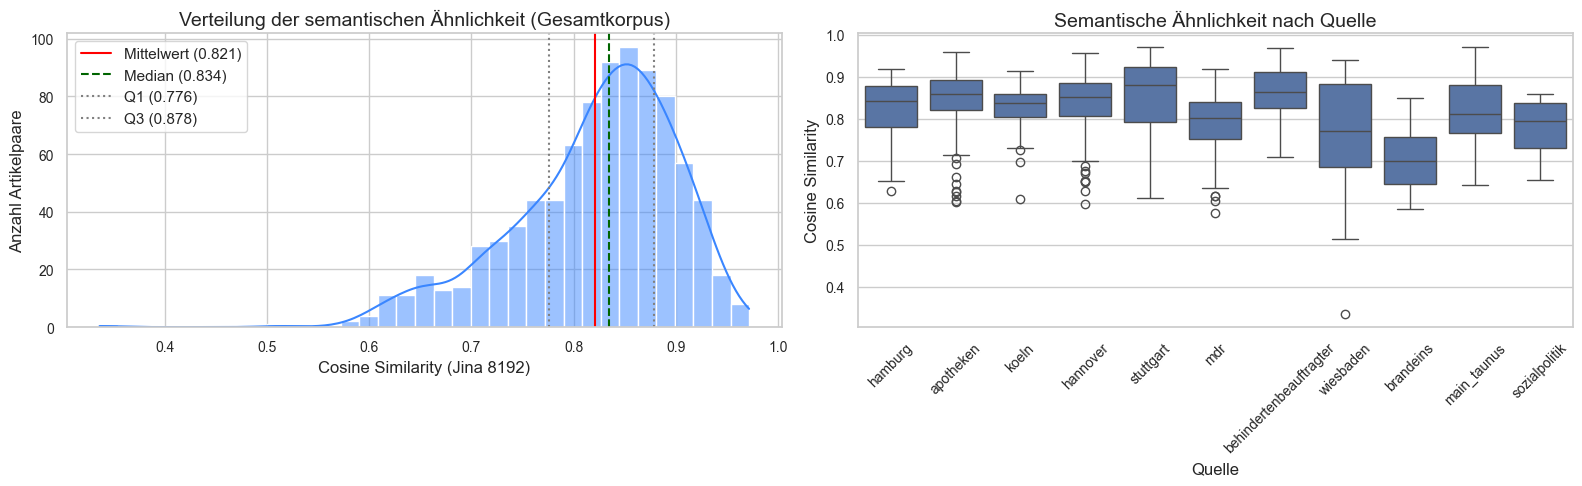

=== Schwellenwert-Verteilung der semantischen Ähnlichkeit ===


,Anzahl,Anteil (%)
sim_category,,
< 0.70 (Niedrig),76,8.616780
0.70 - 0.80 (Moderat),206,23.356009
0.80 - 0.85 (Gut),232,26.303855
0.85 - 0.90 (Sehr gut),244,27.664399
>= 0.90 (Exzellent),124,14.058957


In [6]:
sim_col = "semantic_similarity_8192" if "semantic_similarity_8192" in df.columns else None

if sim_col:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    mean_sim = df[sim_col].mean()
    median_sim = df[sim_col].median()
    q25, q75 = df[sim_col].quantile(0.25), df[sim_col].quantile(0.75)
    
    sns.histplot(df[sim_col], kde=True, bins=35, color="#3a86ff", ax=axes[0])
    axes[0].axvline(mean_sim, color="red", linestyle="-", label=f"Mittelwert ({mean_sim:.3f})")
    axes[0].axvline(median_sim, color="darkgreen", linestyle="--", label=f"Median ({median_sim:.3f})")
    axes[0].axvline(q25, color="gray", linestyle=":", label=f"Q1 ({q25:.3f})")
    axes[0].axvline(q75, color="gray", linestyle=":", label=f"Q3 ({q75:.3f})")
    axes[0].set_title("Verteilung der semantischen Ähnlichkeit (Gesamtkorpus)")
    axes[0].set_xlabel("Cosine Similarity (Jina 8192)")
    axes[0].set_ylabel("Anzahl Artikelpaare")
    axes[0].legend()
    
    sns.boxplot(data=df, x="source", y=sim_col, color="#4C72B0", ax=axes[1])
    axes[1].set_title("Semantische Ähnlichkeit nach Quelle")
    axes[1].set_xlabel("Quelle")
    axes[1].set_ylabel("Cosine Similarity")
    axes[1].tick_params(axis="x", rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    thresholds = [0.0, 0.70, 0.80, 0.85, 0.90, 1.01]
    labels = ["< 0.70 (Niedrig)", "0.70 - 0.80 (Moderat)", "0.80 - 0.85 (Gut)", "0.85 - 0.90 (Sehr gut)", ">= 0.90 (Exzellent)"]
    df["sim_category"] = pd.cut(df[sim_col], bins=thresholds, labels=labels, right=False)
    
    sim_dist = df["sim_category"].value_counts(sort=False).to_frame(name="Anzahl")
    sim_dist["Anteil (%)"] = (sim_dist["Anzahl"] / len(df)) * 100
    print("=== Schwellenwert-Verteilung der semantischen Ähnlichkeit ===")
    display(sim_dist)


## 5. Bidirektionale Named Entity Analyse (NER) & Faktenerhalt vs. Faktentreue

In dieser Sektion untersuchen wir die Beibehaltung von Fakten und Eigennamen (Personen, Orte, Organisationen) beim Übergang von Alltagssprache zu Leichter Sprache.

### Zentrale Fragestellungen:
1. **Faktenerhalt ($AS \to LS$)**: Welche Entitäten bleiben erhalten und welcher Anteil geht verloren?
2. **Faktentreue ($LS \to AS$)**: Führt Leichte Sprache neue Entitäten ein, die nicht im Originaltext stehen?
3. **Richtungsasymmetrie**: Ist der Erhalt in beide Richtungen gleich groß oder unterscheiden sich die Raten signifikant?
4. **Ursachen von Entitätsverlusten**: Liegt ein tatsächlicher Informationsverlust vor oder werden Eigennamen bewusst zu Gattungsbegriffen generalisiert bzw. umschrieben (z. B. *"Bundesagentur für Arbeit"* $\to$ *"Amt"*, *"Krebsregister"* $\to$ *"Sammlung von Infos"*?)


/var/folders/b4/clxxd_yn5655dz4hq58pqznh0000gn/T/ipykernel_62118/518801772.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_ner_melted, x="Richtung", y="Recall", palette=["#2b5c8f", "#e27c38"], ax=axes[1])


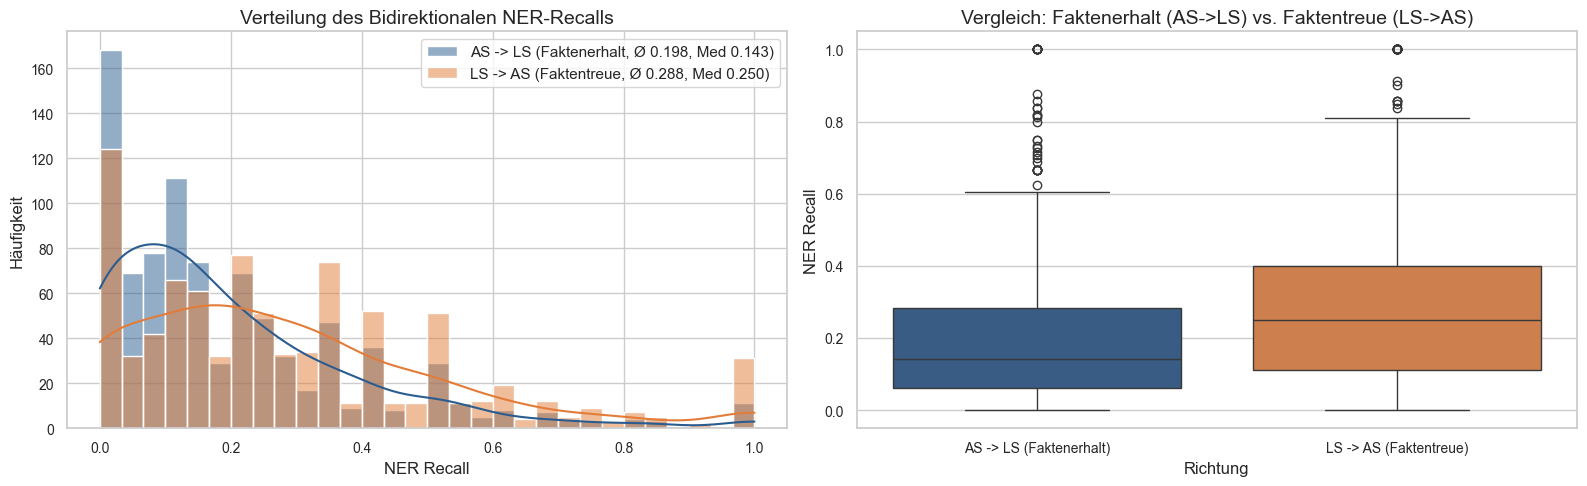

Paarweiser t-Test (AS->LS vs. LS->AS): t = -11.280, p = 1.163e-27
Wilcoxon Signed-Rank Test: W = 64924.500, p = 5.102e-32
-> Fazit: Faktentreue (LS->AS: 28.8%) ist signifikant höher als Faktenerhalt (AS->LS: 19.8%),
   da Leichte Sprache den Großteil der Entitäten aus AS streicht/generalisiert, die verbleibenden aber überwiegend aus AS stammen.


In [7]:
# 5.1 Verteilung des bidirektionalen NER-Recall (Histogramme & Boxplots)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

mean_as_ls = df["ner_recall_as_ls"].mean()
mean_ls_as = df["ner_recall_ls_as"].mean()
median_as_ls = df["ner_recall_as_ls"].median()
median_ls_as = df["ner_recall_ls_as"].median()

# Histogramm / KDE beider Richtungen
sns.histplot(df["ner_recall_as_ls"], kde=True, color="#2b5c8f", label=f"AS -> LS (Faktenerhalt, Ø {mean_as_ls:.3f}, Med {median_as_ls:.3f})", bins=30, alpha=0.5, ax=axes[0])
sns.histplot(df["ner_recall_ls_as"], kde=True, color="#e27c38", label=f"LS -> AS (Faktentreue, Ø {mean_ls_as:.3f}, Med {median_ls_as:.3f})", bins=30, alpha=0.5, ax=axes[0])
axes[0].set_title("Verteilung des Bidirektionalen NER-Recalls")
axes[0].set_xlabel("NER Recall")
axes[0].set_ylabel("Häufigkeit")
axes[0].legend()

# Boxplot des direkten Vergleichs beider Richtungen
df_ner_melted = df.melt(id_vars=["source"], value_vars=["ner_recall_as_ls", "ner_recall_ls_as"],
                        var_name="Richtung", value_name="Recall")
df_ner_melted["Richtung"] = df_ner_melted["Richtung"].map({
    "ner_recall_as_ls": "AS -> LS (Faktenerhalt)",
    "ner_recall_ls_as": "LS -> AS (Faktentreue)"
})

sns.boxplot(data=df_ner_melted, x="Richtung", y="Recall", palette=["#2b5c8f", "#e27c38"], ax=axes[1])
axes[1].set_title("Vergleich: Faktenerhalt (AS->LS) vs. Faktentreue (LS->AS)")
axes[1].set_ylabel("NER Recall")

plt.tight_layout()
plt.show()

# Statistische Signifikanzprüfung des Richtungsunterschieds
t_stat_ner, p_val_ner = stats.ttest_rel(df["ner_recall_as_ls"].dropna(), df["ner_recall_ls_as"].dropna())
w_stat_ner, p_val_w_ner = stats.wilcoxon(df["ner_recall_as_ls"].dropna(), df["ner_recall_ls_as"].dropna())

print(f"Paarweiser t-Test (AS->LS vs. LS->AS): t = {t_stat_ner:.3f}, p = {p_val_ner:.3e}")
print(f"Wilcoxon Signed-Rank Test: W = {w_stat_ner:.3f}, p = {p_val_w_ner:.3e}")
print(f"-> Fazit: Faktentreue (LS->AS: {mean_ls_as:.1%}) ist signifikant höher als Faktenerhalt (AS->LS: {mean_as_ls:.1%}),")
print("   da Leichte Sprache den Großteil der Entitäten aus AS streicht/generalisiert, die verbleibenden aber überwiegend aus AS stammen.")


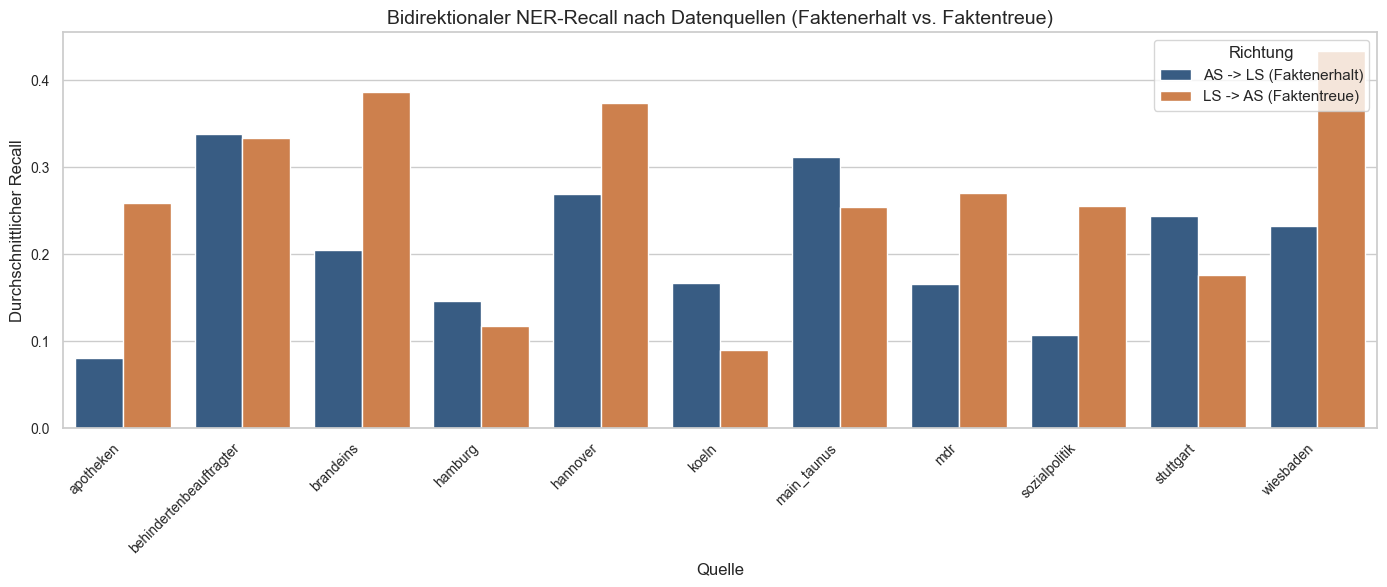

=== Detaillierte NER-Statistik nach Datenquellen ===


,Paare,Ø_NER_AS_LS,Med_NER_AS_LS,Ø_NER_LS_AS,Med_NER_LS_AS,Ø_Ent_AS,Ø_Ent_LS
source,,,,,,,
apotheken,154,0.081,0.051,0.259,0.211,25.883,7.091
behindertenbeauftragter,49,0.338,0.344,0.334,0.306,15.551,19.327
brandeins,18,0.205,0.211,0.387,0.292,5.944,4.944
hamburg,49,0.147,0.111,0.118,0.091,16.204,16.490
hannover,229,0.270,0.234,0.374,0.333,19.760,12.598
koeln,37,0.167,0.143,0.090,0.069,14.486,27.081
main_taunus,34,0.311,0.292,0.254,0.250,6.765,6.059
mdr,222,0.166,0.137,0.271,0.231,23.045,13.027
sozialpolitik,14,0.107,0.090,0.255,0.194,24.429,12.357


In [8]:
# 5.2 Bidirektionaler NER-Vergleich nach Datenquellen (wie im Weekly Report)
mean_ner_by_source = df.groupby("source")[["ner_recall_as_ls", "ner_recall_ls_as"]].mean().reset_index()
mean_ner_by_source.columns = ["Quelle", "AS -> LS (Faktenerhalt)", "LS -> AS (Faktentreue)"]
ner_plot_df = mean_ner_by_source.melt(id_vars="Quelle", var_name="Richtung", value_name="Recall")

plt.figure(figsize=(14, 6))
sns.barplot(data=ner_plot_df, x="Quelle", y="Recall", hue="Richtung", palette=["#2b5c8f", "#e27c38"])
plt.title("Bidirektionaler NER-Recall nach Datenquellen (Faktenerhalt vs. Faktentreue)")
plt.xlabel("Quelle")
plt.ylabel("Durchschnittlicher Recall")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Richtung", loc="upper right")
plt.tight_layout()
plt.show()

# Tabelle nach Quelle
print("=== Detaillierte NER-Statistik nach Datenquellen ===")
ner_summary_source = df.groupby("source").agg(
    Paare=("ner_recall_as_ls", "count"),
    Ø_NER_AS_LS=("ner_recall_as_ls", "mean"),
    Med_NER_AS_LS=("ner_recall_as_ls", "median"),
    Ø_NER_LS_AS=("ner_recall_ls_as", "mean"),
    Med_NER_LS_AS=("ner_recall_ls_as", "median"),
    Ø_Ent_AS=("as_ent_count", "mean"),
    Ø_Ent_LS=("ls_ent_count", "mean")
)
display(ner_summary_source.round(3))


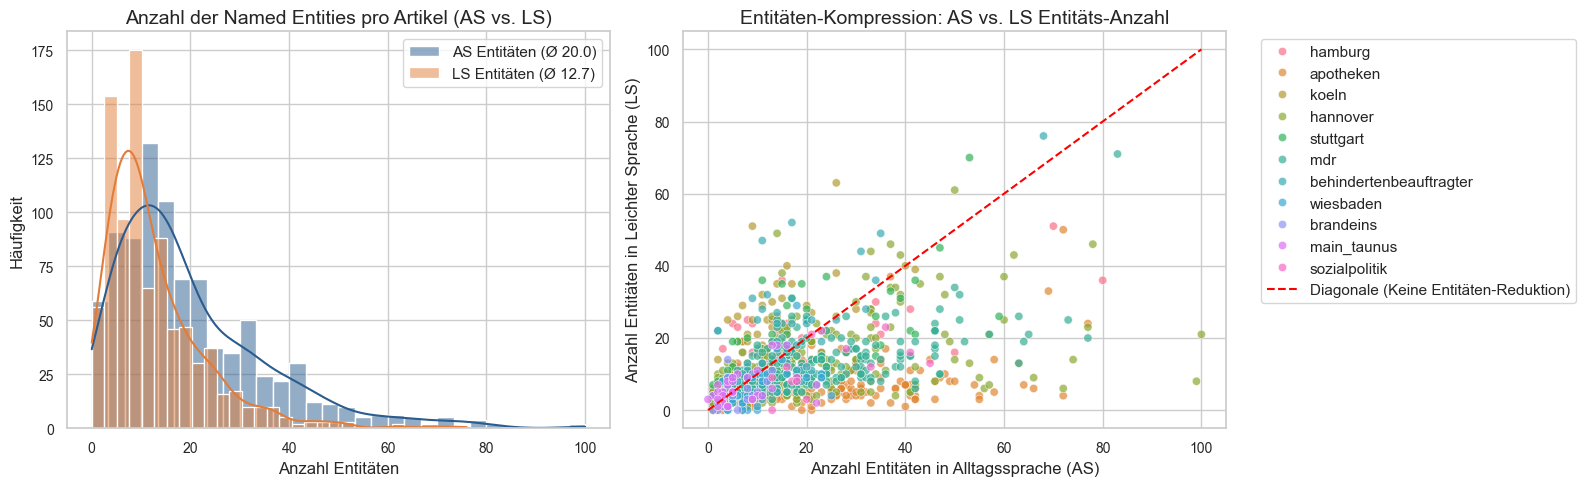

Gesamte Entitäten in AS: 17,597
Gesamte Entitäten in LS: 11,185
-> Absolute Entitäten-Reduktion im Gesamtkorpus: 36.4%


In [9]:
# 5.3 Entitäten-Anzahlen & Entitäten-Kompression
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Verteilung der Entitätenanzahlen
sns.histplot(df["as_ent_count"], kde=True, color="#2b5c8f", label=f"AS Entitäten (Ø {df['as_ent_count'].mean():.1f})", bins=30, alpha=0.5, ax=axes[0])
sns.histplot(df["ls_ent_count"], kde=True, color="#e27c38", label=f"LS Entitäten (Ø {df['ls_ent_count'].mean():.1f})", bins=30, alpha=0.5, ax=axes[0])
axes[0].set_title("Anzahl der Named Entities pro Artikel (AS vs. LS)")
axes[0].set_xlabel("Anzahl Entitäten")
axes[0].set_ylabel("Häufigkeit")
axes[0].legend()

# Scatterplot AS Entitäten vs LS Entitäten
sns.scatterplot(data=df, x="as_ent_count", y="ls_ent_count", hue="source", alpha=0.7, ax=axes[1])
max_ents = max(df["as_ent_count"].max(), df["ls_ent_count"].max())
axes[1].plot([0, max_ents], [0, max_ents], color="red", linestyle="--", label="Diagonale (Keine Entitäten-Reduktion)")
axes[1].set_title("Entitäten-Kompression: AS vs. LS Entitäts-Anzahl")
axes[1].set_xlabel("Anzahl Entitäten in Alltagssprache (AS)")
axes[1].set_ylabel("Anzahl Entitäten in Leichter Sprache (LS)")
axes[1].legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

# Entitäten-Reduktionsrate
ent_reduction = 1.0 - (df["ls_ent_count"].sum() / df["as_ent_count"].sum())
print(f"Gesamte Entitäten in AS: {df['as_ent_count'].sum():,}")
print(f"Gesamte Entitäten in LS: {df['ls_ent_count'].sum():,}")
print(f"-> Absolute Entitäten-Reduktion im Gesamtkorpus: {ent_reduction:.1%}")


In [10]:
# 5.4 Qualitative Einzelfallanalyse: Welche Entitäten bleiben erhalten und welche gehen verloren?
nlp = spacy.load("de_core_news_lg")

# Auswahl von drei interessanten Fallbeispielen:
# 1. Hoher NER-Recall (starke Faktenübernahme)
# 2. Niedriger NER-Recall (starke Generalisierung / Umschreibung)
# 3. Typischer Fall (mittlerer Erhalt)

high_recall_idx = df["ner_recall_as_ls"].idxmax()
low_recall_idx = df[df["as_ent_count"] > 10]["ner_recall_as_ls"].idxmin()
median_recall_idx = (df["ner_recall_as_ls"] - df["ner_recall_as_ls"].median()).abs().idxmin()

selected_indices = [
    ("Hoher Faktenerhalt (AS -> LS)", high_recall_idx),
    ("Starke Generalisierung / Entitätsverlust", low_recall_idx),
    ("Repräsentativer Median-Fall", median_recall_idx)
]

for title, idx in selected_indices:
    row = df.loc[idx]
    as_doc = nlp(str(row["as_text"]))
    ls_doc = nlp(str(row["ls_text"]))
    
    as_ents = set([ent.text.strip() for ent in as_doc.ents])
    ls_ents = set([ent.text.strip() for ent in ls_doc.ents])
    
    overlap = as_ents.intersection(ls_ents)
    lost = as_ents - ls_ents
    added = ls_ents - as_ents
    
    print("=================================================================")
    print(f"FALLBEISPIEL: {title} [Quelle: {row['source']}]")
    print(f"NER-Recall AS->LS: {row['ner_recall_as_ls']:.1%} | NER-Recall LS->AS: {row['ner_recall_ls_as']:.1%}")
    print(f"Semantische Ähnlichkeit (Jina 8192): {row['semantic_similarity_8192']:.3f}")
    print(f"Tokens: AS = {row['as_tokens']} | LS = {row['ls_tokens']}")
    print("-----------------------------------------------------------------")
    print(f"Erhaltene Entitäten ({len(overlap)}): {list(overlap)[:8]}")
    print(f"Verlorene Entitäten ({len(lost)}):    {list(lost)[:8]}")
    print(f"Neue/modifizierte Entitäten in LS ({len(added)}): {list(added)[:8]}")
    print("-----------------------------------------------------------------")
    print(f"AS-Textausschnitt: {str(row['as_text'])[:220]}...")
    print(f"LS-Textausschnitt: {str(row['ls_text'])[:220]}...")
    print()


FALLBEISPIEL: Hoher Faktenerhalt (AS -> LS) [Quelle: hannover]
NER-Recall AS->LS: 100.0% | NER-Recall LS->AS: 25.0%
Semantische Ähnlichkeit (Jina 8192): 0.745
Tokens: AS = 96 | LS = 321
-----------------------------------------------------------------
Erhaltene Entitäten (1): ['Telefonseelsorge']
Verlorene Entitäten (0):    []
Neue/modifizierte Entitäten in LS (3): ['Anonym', 'Stadt', 'www.telefonseelsorge.de']
-----------------------------------------------------------------
AS-Textausschnitt: anonym, vertraulich, gebührenfrei Telefonseelsorge Rund um die Uhr erreichbar: Wem Einsamkeit, Konflikte, Krankheit, Verlust Angst machen oder Sorge bereiten, findet hier spontan geschulte Gesprächspartner*innen mit offe...
LS-Textausschnitt: Telefonberatung bei Problemen und Sorgen Rund um die Uhr können ältere Menschen die Telefonberatung anrufen. Bei der Telefonberatung können ältere Menschen über Probleme sprechen. Oder über Sorgen. Seelsorge ist der Name...

FALLBEISPIEL: Starke Generalisie

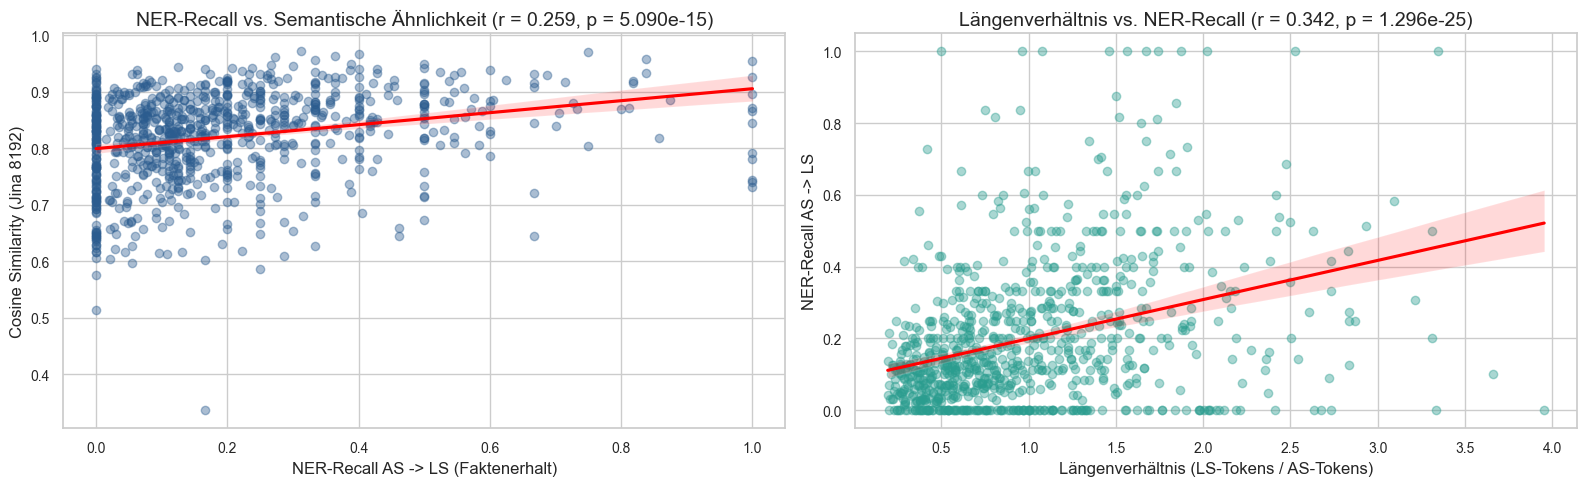

Erkenntnis:
1. Korrelation NER vs. Ähnlichkeit (r = 0.259): Die semantische Ähnlichkeit bleibt selbst bei geringem NER-Recall hoch,
   weil Kernaussagen durch Paraphrasen und Deskriptionen übermittelt werden, ohne Eigennamen wortwörtlich zu wiederholen.
2. Korrelation Token-Ratio vs. NER (r = 0.342): Längere Erklärungen in LS führen nicht zu einer signifikant höheren Übernahme von Entitäten.


In [11]:
# 5.5 Korrelation: NER-Recall vs. Semantische Ähnlichkeit & Längenverhältnis
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scatterplot: NER-Recall vs. Semantische Ähnlichkeit
sns.regplot(data=df, x="ner_recall_as_ls", y="semantic_similarity_8192", 
            scatter_kws={"alpha": 0.4, "color": "#2b5c8f"}, line_kws={"color": "red"}, ax=axes[0])
corr_ner_sim, p_ner_sim = stats.pearsonr(df["ner_recall_as_ls"].dropna(), df["semantic_similarity_8192"].dropna())
axes[0].set_title(f"NER-Recall vs. Semantische Ähnlichkeit (r = {corr_ner_sim:.3f}, p = {p_ner_sim:.3e})")
axes[0].set_xlabel("NER-Recall AS -> LS (Faktenerhalt)")
axes[0].set_ylabel("Cosine Similarity (Jina 8192)")

# Scatterplot: NER-Recall vs. Token-Ratio
sns.regplot(data=df, x="ratio_ls_as", y="ner_recall_as_ls", 
            scatter_kws={"alpha": 0.4, "color": "#2a9d8f"}, line_kws={"color": "red"}, ax=axes[1])
corr_ner_ratio, p_ner_ratio = stats.pearsonr(df["ratio_ls_as"].dropna(), df["ner_recall_as_ls"].dropna())
axes[1].set_title(f"Längenverhältnis vs. NER-Recall (r = {corr_ner_ratio:.3f}, p = {p_ner_ratio:.3e})")
axes[1].set_xlabel("Längenverhältnis (LS-Tokens / AS-Tokens)")
axes[1].set_ylabel("NER-Recall AS -> LS")

plt.tight_layout()
plt.show()

print("Erkenntnis:")
print(f"1. Korrelation NER vs. Ähnlichkeit (r = {corr_ner_sim:.3f}): Die semantische Ähnlichkeit bleibt selbst bei geringem NER-Recall hoch,")
print("   weil Kernaussagen durch Paraphrasen und Deskriptionen übermittelt werden, ohne Eigennamen wortwörtlich zu wiederholen.")
print(f"2. Korrelation Token-Ratio vs. NER (r = {corr_ner_ratio:.3f}): Längere Erklärungen in LS führen nicht zu einer signifikant höheren Übernahme von Entitäten.")


## 6. Type-Token Ratio (TTR) Analyse & Längen-Bias

Die klassische **Type-Token Ratio** ($TTR = V/N$) beschreibt den Anteil einzigartiger Wörter an der Gesamtwortzahl.

> [!WARNING]
> **Bekannter TTR-Längen-Bias (Herdan's Law / Zipf's Law):**
> Da die Anzahl neuer Wörter in einem Text mit wachsender Länge degressiv ansteigt, fällt die TTR bei längeren Texten mathematisch bedingt ab. Dies führt dazu, dass längere Alltagssprachen-Texte scheinbar eine geringere TTR haben als kurze Leichte-Sprache-Texte.


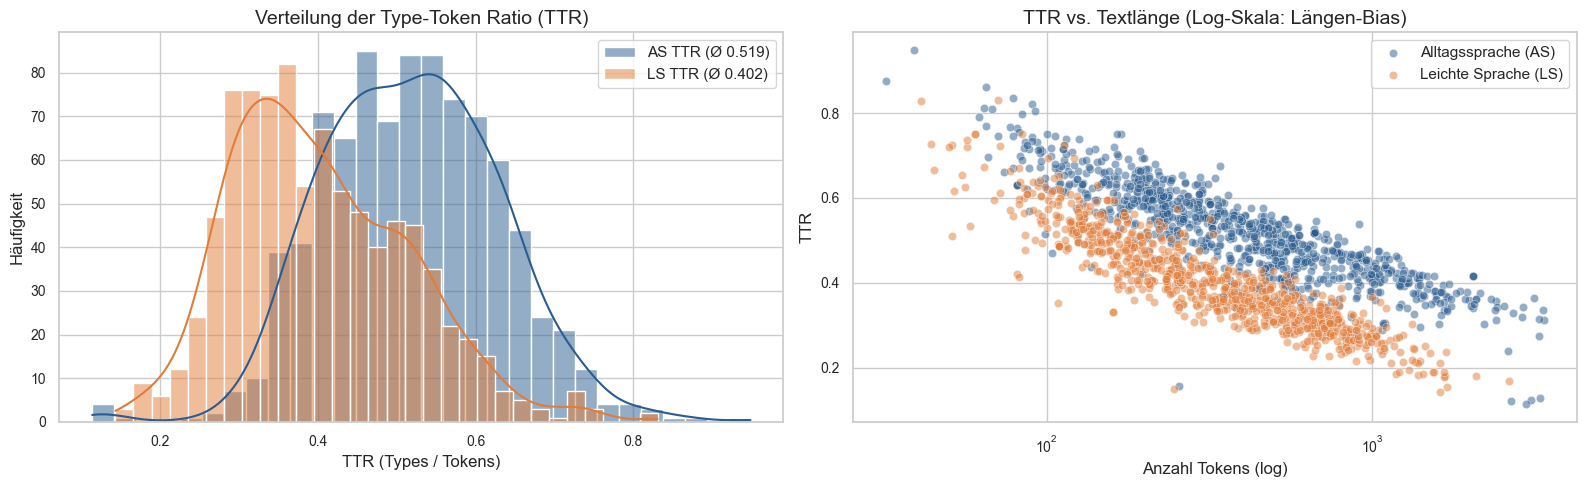

Paarweiser t-Test TTR (AS vs. LS): t = 36.712, p = 9.494e-180


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 6.1 Verteilung TTR: AS vs. LS
sns.histplot(df["as_ttr"], kde=True, color="#2b5c8f", label=f"AS TTR (Ø {df['as_ttr'].mean():.3f})", bins=30, alpha=0.5, ax=axes[0])
sns.histplot(df["ls_ttr"], kde=True, color="#e27c38", label=f"LS TTR (Ø {df['ls_ttr'].mean():.3f})", bins=30, alpha=0.5, ax=axes[0])
axes[0].set_title("Verteilung der Type-Token Ratio (TTR)")
axes[0].set_xlabel("TTR (Types / Tokens)")
axes[0].set_ylabel("Häufigkeit")
axes[0].legend()

# 6.2 Längen-Bias-Visualisierung: TTR vs. Tokenanzahl
sns.scatterplot(data=df, x="as_tokens", y="as_ttr", color="#2b5c8f", alpha=0.5, label="Alltagssprache (AS)", ax=axes[1])
sns.scatterplot(data=df, x="ls_tokens", y="ls_ttr", color="#e27c38", alpha=0.5, label="Leichte Sprache (LS)", ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_title("TTR vs. Textlänge (Log-Skala: Längen-Bias)")
axes[1].set_xlabel("Anzahl Tokens (log)")
axes[1].set_ylabel("TTR")
axes[1].legend()

plt.tight_layout()
plt.show()

# Statistische Auswertung des TTR-Unterschieds
t_stat, p_val = stats.ttest_rel(df["as_ttr"].dropna(), df["ls_ttr"].dropna())
print(f"Paarweiser t-Test TTR (AS vs. LS): t = {t_stat:.3f}, p = {p_val:.3e}")


## 7. Moving-Average Type-Token Ratio (MATTR)

Die **Moving-Average Type-Token Ratio (MATTR)** löst das Problem des Längen-Bias, indem die TTR über ein gleitendes Fenster fester Größe (z. B. $W=50$) gemittelt wird.

Dadurch wird die lexikalische Diversität unabhängig von der Gesamtlänge des Artikels messbar. In Leichter Sprache wird bewusst ein vereinfachtes, wiederholtes Vokabular gewählt, weshalb die MATTR von LS typischerweise signifikant unter der von AS liegt.


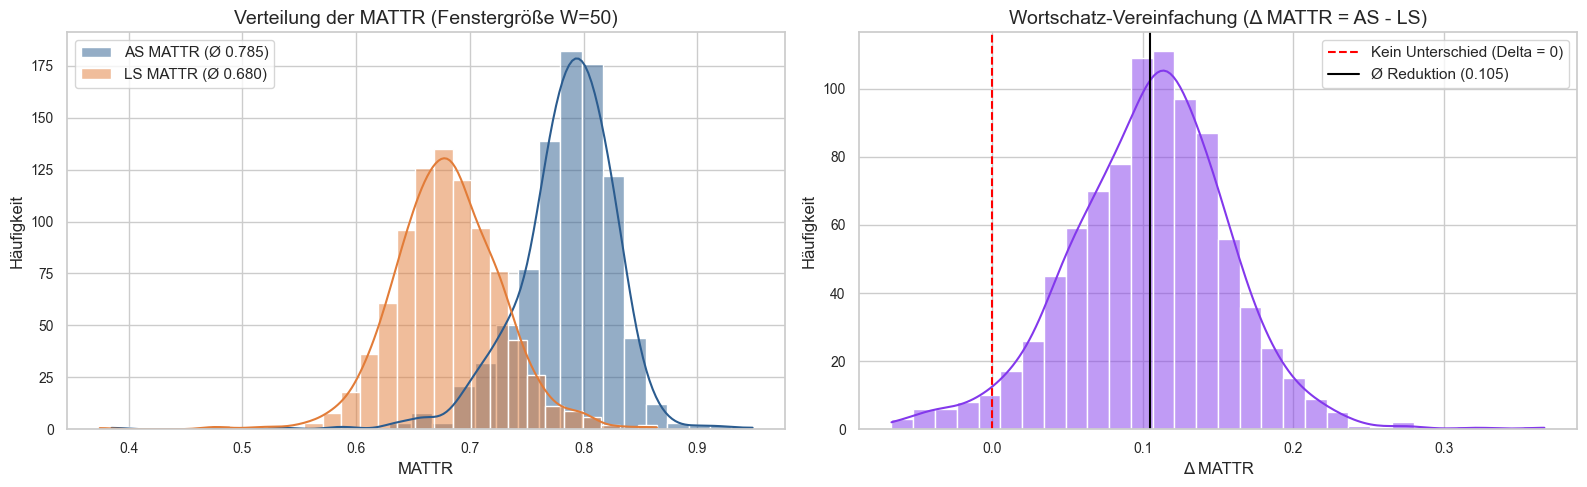

Paarweiser t-Test MATTR (AS vs. LS): t = 58.800, p = 3.124e-307


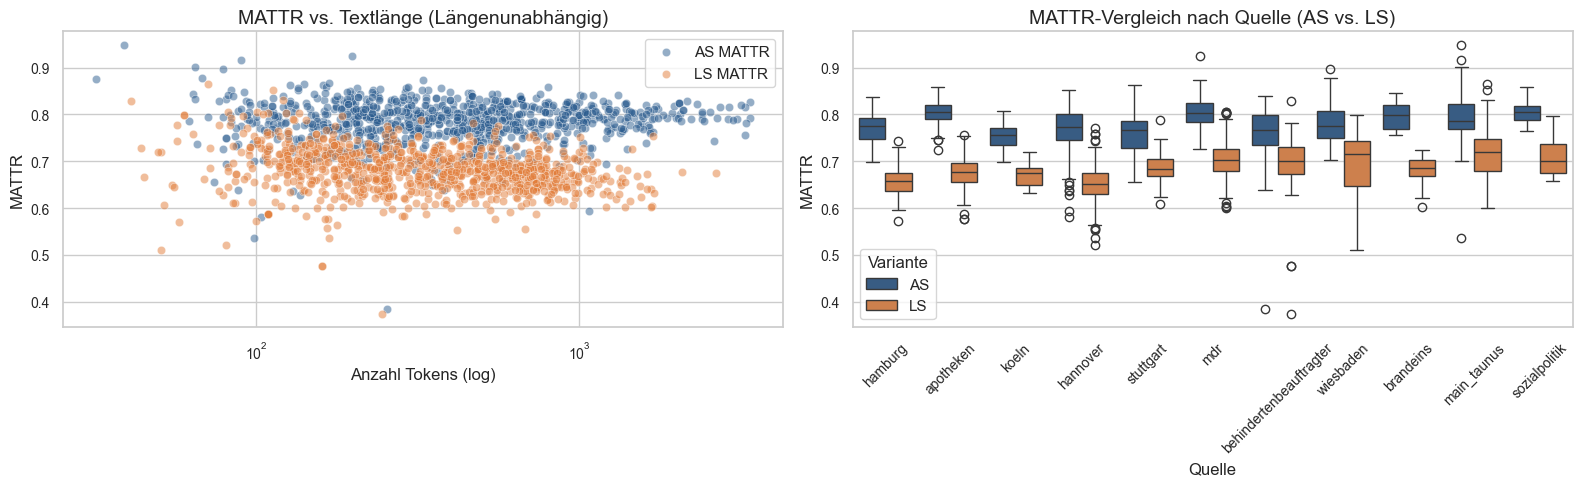

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 7.1 Verteilung MATTR: AS vs. LS
sns.histplot(df["as_mattr"], kde=True, color="#2b5c8f", label=f"AS MATTR (Ø {df['as_mattr'].mean():.3f})", bins=30, alpha=0.5, ax=axes[0])
sns.histplot(df["ls_mattr"], kde=True, color="#e27c38", label=f"LS MATTR (Ø {df['ls_mattr'].mean():.3f})", bins=30, alpha=0.5, ax=axes[0])
axes[0].set_title("Verteilung der MATTR (Fenstergröße W=50)")
axes[0].set_xlabel("MATTR")
axes[0].set_ylabel("Häufigkeit")
axes[0].legend()

# 7.2 Differenz (Delta MATTR = AS - LS)
df["delta_mattr"] = df["as_mattr"] - df["ls_mattr"]
sns.histplot(df["delta_mattr"], kde=True, color="#8338ec", bins=30, ax=axes[1])
axes[1].axvline(0.0, color="red", linestyle="--", label="Kein Unterschied (Delta = 0)")
axes[1].axvline(df["delta_mattr"].mean(), color="black", linestyle="-", label=f"Ø Reduktion ({df['delta_mattr'].mean():.3f})")
axes[1].set_title("Wortschatz-Vereinfachung (Δ MATTR = AS - LS)")
axes[1].set_xlabel("Δ MATTR")
axes[1].set_ylabel("Häufigkeit")
axes[1].legend()

plt.tight_layout()
plt.show()

# Statistische Auswertung des MATTR-Unterschieds
t_stat_m, p_val_m = stats.ttest_rel(df["as_mattr"].dropna(), df["ls_mattr"].dropna())
print(f"Paarweiser t-Test MATTR (AS vs. LS): t = {t_stat_m:.3f}, p = {p_val_m:.3e}")

# 7.3 Direkter Vergleich: TTR vs. MATTR nach Textlänge & Quellen-Boxplot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.scatterplot(data=df, x="as_tokens", y="as_mattr", color="#2b5c8f", alpha=0.5, label="AS MATTR", ax=axes[0])
sns.scatterplot(data=df, x="ls_tokens", y="ls_mattr", color="#e27c38", alpha=0.5, label="LS MATTR", ax=axes[0])
axes[0].set_xscale("log")
axes[0].set_title("MATTR vs. Textlänge (Längenunabhängig)")
axes[0].set_xlabel("Anzahl Tokens (log)")
axes[0].set_ylabel("MATTR")
axes[0].legend()

df_mattr_melted = df.melt(id_vars=["source"], value_vars=["as_mattr", "ls_mattr"], 
                          var_name="Variante", value_name="MATTR")
df_mattr_melted["Variante"] = df_mattr_melted["Variante"].map({"as_mattr": "AS", "ls_mattr": "LS"})

sns.boxplot(data=df_mattr_melted, x="source", y="MATTR", hue="Variante", palette=["#2b5c8f", "#e27c38"], ax=axes[1])
axes[1].set_title("MATTR-Vergleich nach Quelle (AS vs. LS)")
axes[1].set_xlabel("Quelle")
axes[1].set_ylabel("MATTR")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


## 8. Multivariate Korrelationen & Gesamttabelle aller Korpusmetriken

Zusammenfassende Übersicht über alle analysierten Dimensionen der Masterarbeit (Semantische Ähnlichkeit, Textlängen, Bidirektionales NER und MATTR-Diversität).


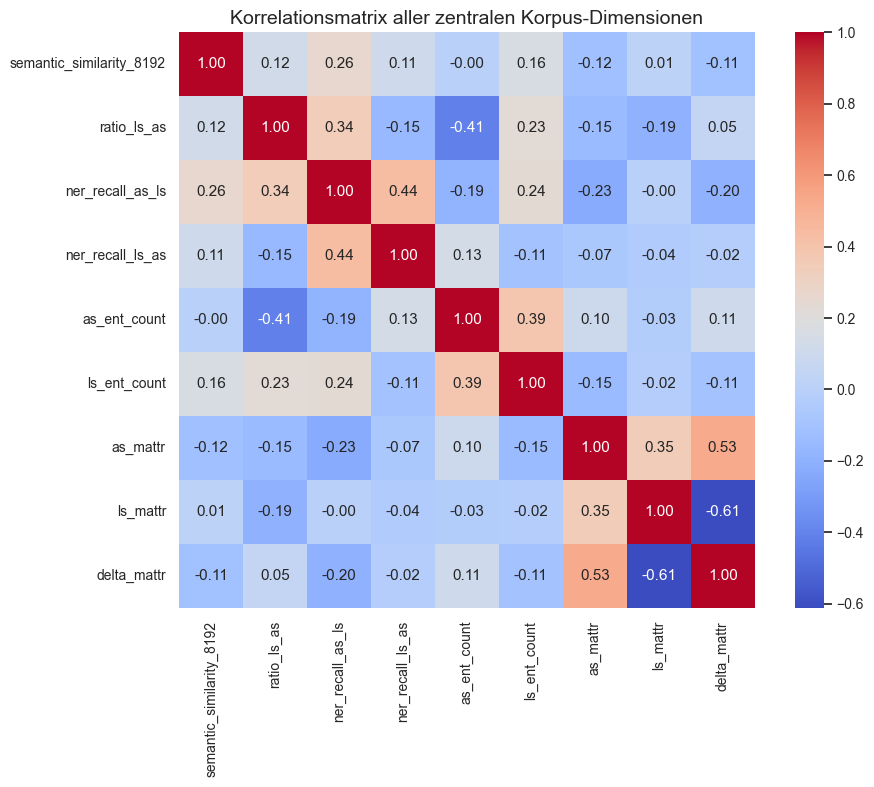

=== Zusammenfassende Statistik aller Korpusmetriken ===


,N,Mittelwert,Std,Min,Q1,Median,Q3,Max
semantic_similarity_8192,882.0,0.821,0.080,0.336,0.776,0.834,0.878,0.972
ratio_ls_as,882.0,0.992,0.613,0.192,0.532,0.835,1.318,3.955
ner_recall_as_ls,882.0,0.198,0.196,0.000,0.061,0.143,0.284,1.000
ner_recall_ls_as,882.0,0.288,0.241,0.000,0.111,0.250,0.400,1.000
as_ent_count,882.0,19.951,15.704,0.000,9.000,15.500,27.000,100.000
ls_ent_count,882.0,12.681,10.231,0.000,6.000,10.000,17.000,76.000
as_mattr,882.0,0.785,0.045,0.385,0.765,0.790,0.812,0.949
ls_mattr,882.0,0.680,0.048,0.374,0.651,0.680,0.710,0.865
delta_mattr,882.0,0.105,0.053,-0.067,0.073,0.107,0.138,0.367


In [14]:
# 8.1 Korrelations-Heatmap aller zentralen Metriken
key_metrics = [
    "semantic_similarity_8192",
    "ratio_ls_as",
    "ner_recall_as_ls",
    "ner_recall_ls_as",
    "as_ent_count",
    "ls_ent_count",
    "as_mattr",
    "ls_mattr",
    "delta_mattr"
]
available_cols = [c for c in key_metrics if c in df.columns]

plt.figure(figsize=(10, 8))
corr_matrix = df[available_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True)
plt.title("Korrelationsmatrix aller zentralen Korpus-Dimensionen")
plt.tight_layout()
plt.show()

# 8.2 Zusammenfassende Kennzahlentabelle für die Masterarbeit
metrics_summary = df[available_cols].describe().T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
metrics_summary.columns = ["N", "Mittelwert", "Std", "Min", "Q1", "Median", "Q3", "Max"]
print("=== Zusammenfassende Statistik aller Korpusmetriken ===")
display(metrics_summary.round(3))
